# Emilio Leon
## Ejercicio Mercado Inmobiliario
### 11/03/2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.core.dtypes.cast import coerce_indexer_dtype
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
housing = fetch_california_housing()

In [3]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
X = pd.DataFrame(housing.data, columns=["medinc", "houseage", "averooms", "avebedrms", "population", "aveoccup", "latitude", "longitude"])
y = pd.DataFrame(housing.target, columns=["medhouseval"])

In [6]:
X.head()

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   medinc      20640 non-null  float64
 1   houseage    20640 non-null  float64
 2   averooms    20640 non-null  float64
 3   avebedrms   20640 non-null  float64
 4   population  20640 non-null  float64
 5   aveoccup    20640 non-null  float64
 6   latitude    20640 non-null  float64
 7   longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [10]:
y.head()

,medhouseval
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [11]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   medhouseval  20640 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB


In [12]:
lr = LinearRegression()

In [13]:
X[["medinc", "houseage", "averooms", "avebedrms", "population", "aveoccup", "latitude", "longitude"]].corr()

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude
medinc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
houseage,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
averooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
avebedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
aveoccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


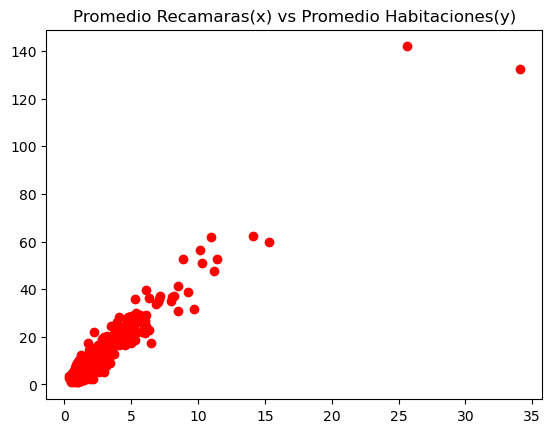

In [14]:
plt.scatter(X["avebedrms"], X["averooms"], color = "red")
plt.title("Promedio Recamaras(x) vs Promedio Habitaciones(y)")
plt.show()

#### El promedio de habitaciones y de Recamaras tiene una relación fuerte

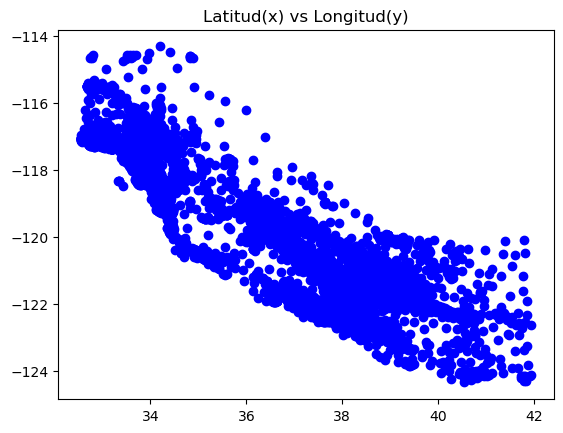

In [15]:
plt.scatter(X["latitude"], X["longitude"], color = "blue")
plt.title("Latitud(x) vs Longitud(y)")
plt.show()

#### La longitud y la latitud también están muy relacionadas, pero negativamente.

#### Por lo que usaremos medinc, houseage, avebedrms, population aveoccup, y latitude, para no tener variables que repitan.

In [16]:
X_analisis = X[["medinc", "houseage", "avebedrms", "population", "aveoccup", "latitude"]]
y_analisis = y

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_analisis, y_analisis, test_size=0.2, random_state=42)

In [18]:
# Entrenamos el algoritmo
lr.fit(X_train, y_train)

LinearRegression()

In [31]:
R2 = lr.score(X_train, y_train)
R2

0.5235529149156704

In [28]:
# Lo usamos para predecir los valores con los que se entrenó, y con los de prueba
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

In [30]:
# Hacemos las métricas
r2 = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
print(r2, mse)

0.5032184434254283 0.650987011959808


In [33]:
# La ecuación del modelo:
intersect_n = lr.intercept_
coeficientes_n = lr.coef_
print("La intersección es: ",intersect_n, ", los coeficientes son: ", coeficientes_n)

La intersección es:  [1.47760738] , los coeficientes son:  [[ 4.31731581e-01  1.84584524e-02  6.93808432e-02  2.60920083e-05
  -4.21067747e-03 -4.79597609e-02]]
